In [1]:
from pyspark.sql import SparkSession

In [2]:
spark = (
    SparkSession.builder.appName("SparkDemo")
    .master("local[*]")
    .config("spark.executor.instances", "2")
    .config("spark.executor.memory", "2g")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)

sc = spark.sparkContext

25/11/10 11:31:18 WARN Utils: Your hostname, Tonys-MacBook-Air-2.local resolves to a loopback address: 127.0.0.1; using 192.168.59.25 instead (on interface en0)
25/11/10 11:31:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/10 11:31:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
text_file = sc.textFile("./data/shakespeare.txt")

In [11]:
# Tokenize, map → (word, 1), reduceByKey → frequencies
counts = (
    text_file.flatMap(lambda line: line.split(" "))
    .map(lambda word: (word, 1))
    .reduceByKey(lambda x, y: x + y)
    .sortBy(lambda l: l[1], ascending=False)
    .filter(lambda x: x[0] != "")
)

In [12]:
output = counts.take(10)

for word, count in output:
    print(f"{f'`{word}`':<10}: {count:,}")

`the`     : 23,197
`I`       : 19,540
`and`     : 18,263
`to`      : 15,592
`of`      : 15,507
`a`       : 12,516
`my`      : 10,824
`in`      : 9,565
`you`     : 9,059
`is`      : 7,831


In [13]:
# Get the top‑10 most frequent words
# Remember: each `x` is a tuple(word, freq)
top10 = counts.takeOrdered(10, key=lambda x: -x[1])
words, freqs = zip(*top10)

In [14]:
from matplotlib import pyplot as plt
import seaborn as sns

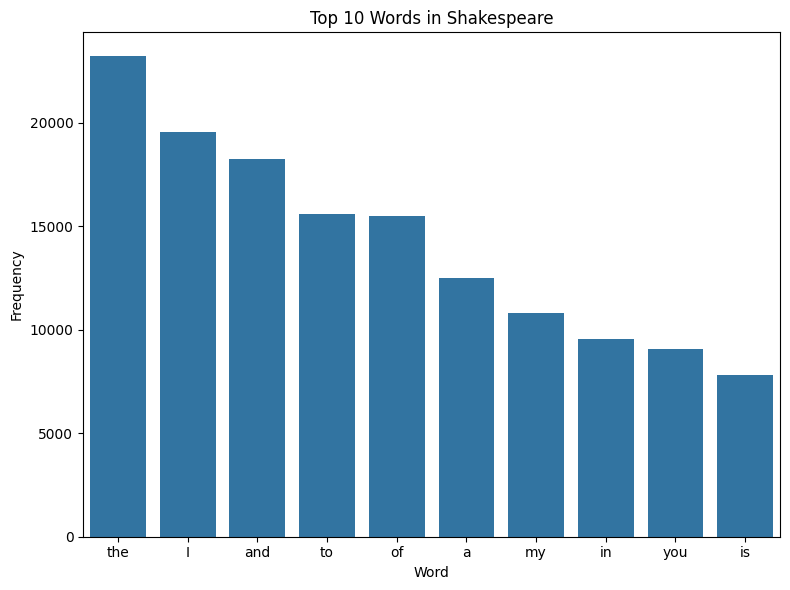

In [15]:
# Plot
_, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=words, y=freqs, ax=ax)
ax.set_title("Top 10 Words in Shakespeare")
ax.set_xlabel("Word")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [16]:
# Remember, ALWAYS close Spark Session and Spark Context!
sc.stop()
spark.stop()